<a href="https://colab.research.google.com/github/youssef12111/facial-emotion-recognition-ai/blob/main/Resnet18_FER_2013_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FER-2013 Facial Emotion Recognition -- ResNet18 + CBAM
This notebook trains a deep learning model to recognise six facial emotions (angry, fear, happy, neutral, sad, surprise) using the FER-2013 dataset downloaded from Kaggle.
The dataset contains around 25,000 training images and 7,000 test images at 48×48 pixels, collected from the web, which makes it noisy and challenging. The disgust class was removed to keep only the six target emotions.
The model is a pretrained ResNet18 with a Convolutional Block Attention Module (CBAM) added after the final layer, and a deeper classification head. CBAM was added because FER-2013 images are small and noisy, so the model needs help focusing on the relevant facial regions like the eyes and mouth rather than background clutter.
Training was split into three phases. Phase 1 trained only the new head and CBAM while the backbone was frozen. Phase 2 unfroze the last residual block using OneCycleLR scheduling. Phase 3 unfroze the second to last block at even smaller learning rates. This gradual approach stops the pretrained ImageNet weights from being overwritten too quickly.
Regularisation included mixup augmentation, label smoothing, boosted class weights for minority emotions, and random erasing. The final evaluation was done using test-time augmentation (TTA) to improve prediction stability.
The notebook produces training curves, a confusion matrix, per-class F1 scores, and examples of correct and misclassified predictions.

In [ ]:
# Libraries for the whole notebook the been used throughout the experiment

import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

# Set the same random seed each time so results stay more consistent.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# Use GPU if available, otherwise use CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Kaggle API setup
from google.colab import files

print('Upload your kaggle.json file when prompted')
uploaded = files.upload()

# Create the Kaggle folder if it does not already exist.
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# Move the kaggle.json file to the correct Kaggle folder.
shutil.move('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))

# Set file permission so Kaggle can use the file safely.
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

print('Kaggle API configured')

Upload your kaggle.json file when prompted


Saving kaggle.json to kaggle.json
Kaggle API configured


In [ ]:
#  Download FER2013 from Kaggle
!pip install kaggle --quiet
!kaggle datasets download -d msambare/fer2013 --unzip -p /content/fer2013
print('Dataset downloaded')

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
  0% 0.00/60.3M [00:00<?, ?B/s]
100% 60.3M/60.3M [00:00<00:00, 1.63GB/s]
Dataset downloaded


In [ ]:


TRAIN_PATH = Path('/content/fer2013/train')
TEST_PATH  = Path('/content/fer2013/test')

# These are the emotion classes used in this notebook.
VALID_CLASSES = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES   = len(VALID_CLASSES)
CLASS_TO_IDX  = {cls: i for i, cls in enumerate(VALID_CLASSES)}

# Set the image size and batch size for training.
IMG_SIZE   = 224
BATCH_SIZE = 64

# Number of epochs used in each training phase.
EPOCHS_P1 = 60
EPOCHS_P2 = 30
EPOCHS_P3 = 25

# Learning rates for each training phase.
LR_P1      = 3e-4
LR_P2_HEAD = 1e-4
LR_P2_L4   = 1e-5
LR_P3_HEAD = 5e-5
LR_P3_L4   = 1e-5
LR_P3_L3   = 5e-6

# Folder for saving outputs such as plots and results.
OUT = Path('/content/drive/MyDrive/FER_JC/FER2013/outputs_v2')
OUT.mkdir(parents=True, exist_ok=True)

print(f'Classes : {VALID_CLASSES}')
print(f'Img size: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch   : {BATCH_SIZE}')

Classes : ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Img size: 224x224
Batch   : 64


In [ ]:


def count_images(split_path, valid_classes):
    # Count how many image files are in each class folder.
    exts = {'.jpg', '.jpeg', '.png'}
    counts = {}

    for cls in valid_classes:
        folder = split_path / cls
        if folder.exists():
            counts[cls] = sum(
                1 for f in folder.iterdir() if f.suffix.lower() in exts
            )
        else:
            counts[cls] = 0
            print(f'Missing folder: {folder}')

    return counts

train_counts = count_images(TRAIN_PATH, VALID_CLASSES)
test_counts = count_images(TEST_PATH, VALID_CLASSES)

print('Train counts:', train_counts)
print('Test counts :', test_counts)
print(f'Train total : {sum(train_counts.values())}')
print(f'Test total  : {sum(test_counts.values())}')

Train counts: {'angry': 3995, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}
Test counts : {'angry': 958, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}
Train total : 28273
Test total  : 7067


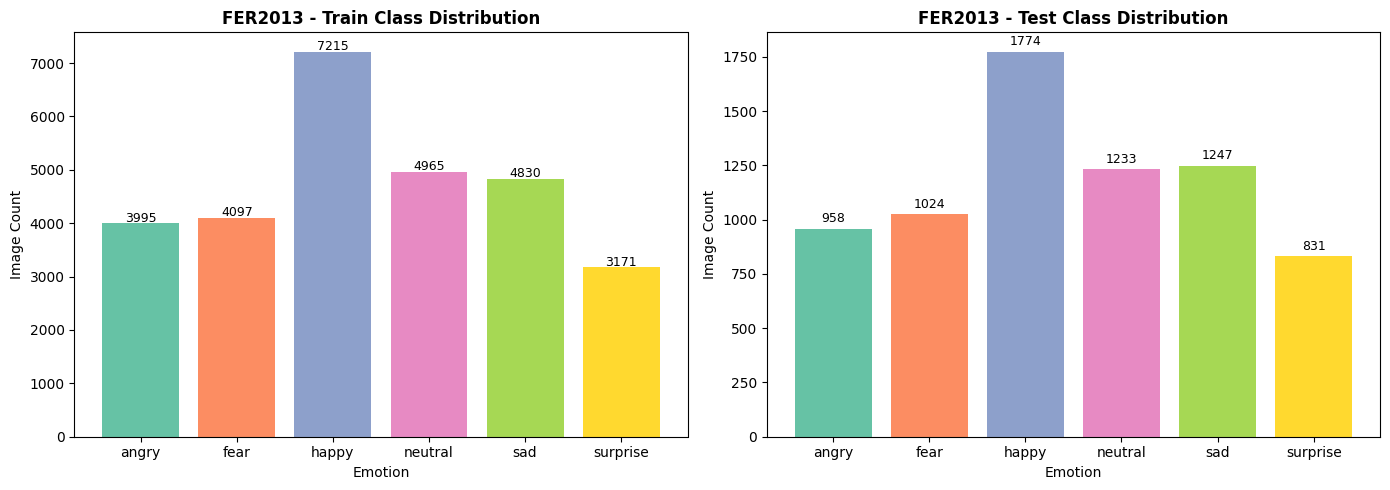

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (split_name, counts) in zip(
    axes,
    [('Train', train_counts), ('Test', test_counts)]
):
    bars = ax.bar(
        counts.keys(),
        counts.values(),
        color=sns.color_palette('Set2', len(counts))
    )

    ax.set_title(
        f'FER2013 - {split_name} Class Distribution',
        fontsize=12,
        fontweight='bold'
    )
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Image Count')

    # Show the image count above each bar.
    for bar, v in zip(bars, counts.values()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 30,
            str(v),
            ha='center',
            fontsize=9
        )

plt.tight_layout()
plt.savefig('fer2013_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

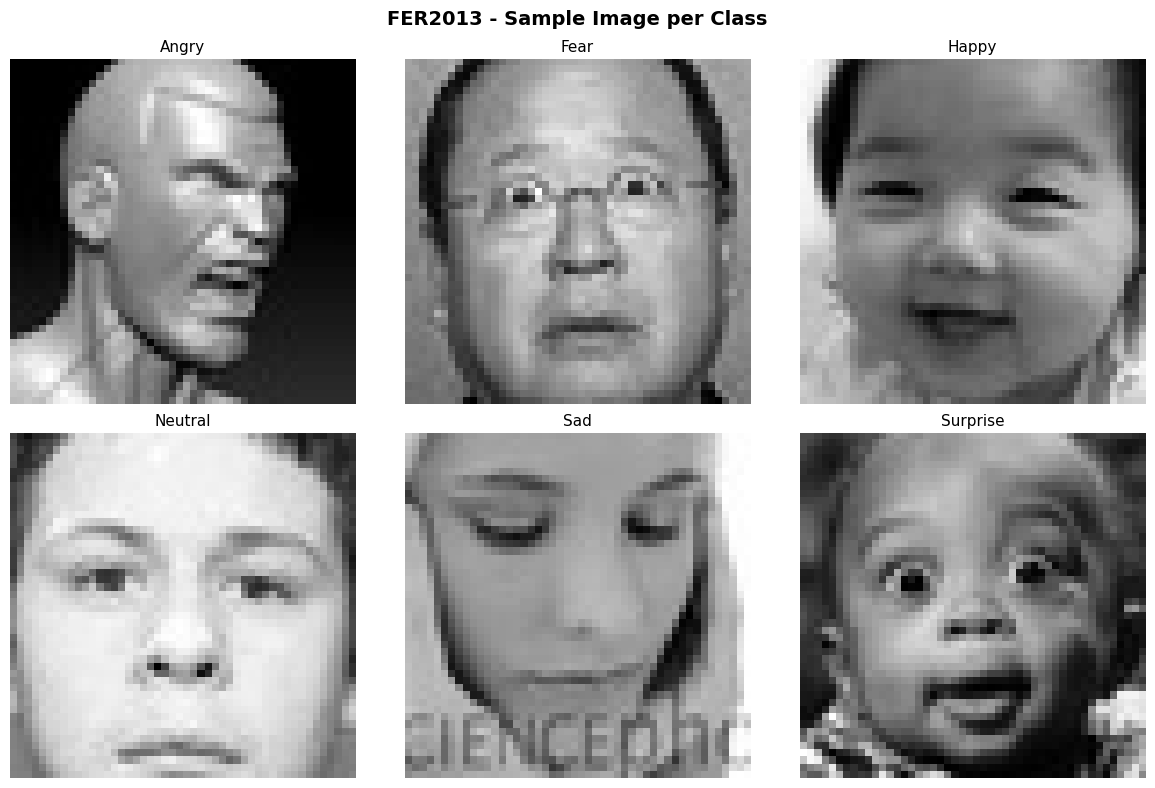

In [ ]:


exts = {'.jpg', '.jpeg', '.png'}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('FER2013 - Sample Image per Class', fontsize=14, fontweight='bold')

for ax, cls in zip(axes.flatten(), VALID_CLASSES):
    folder = TRAIN_PATH / cls
    imgs = [f for f in sorted(folder.iterdir()) if f.suffix.lower() in exts]

    # Pick one random image from each class folder.
    img = Image.open(random.choice(imgs)).convert('L')

    ax.imshow(img, cmap='gray')
    ax.set_title(cls.capitalize(), fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('fer2013_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

# Training transforms add small changes to the images
# so the model can learn better and not depend on one exact view.
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
    ),
    transforms.RandomResizedCrop(
        size=IMG_SIZE,
        scale=(0.80, 1.0),
        ratio=(0.90, 1.10)
    ),
    # Move the face a little so the model learns to handle small shifts.
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    # Hide a small random part of the image to make the model use more than one face area.
    transforms.RandomErasing(p=0.4, scale=(0.02, 0.20))
])

# Validation and test transforms keep the image clean and consistent.
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class FERDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Open one image and apply the chosen transforms.
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


def collect_paths(split_path, valid_classes):
    # Collect all image paths and their class labels from the dataset folders.
    exts = {'.jpg', '.jpeg', '.png'}
    paths = []
    labels = []

    for cls in valid_classes:
        folder = split_path / cls
        cls_idx = valid_classes.index(cls)

        if not folder.exists():
            print(f'Missing: {folder}')
            continue

        for f in sorted(folder.iterdir()):
            if f.suffix.lower() in exts:
                paths.append(str(f))
                labels.append(cls_idx)

    return paths, labels


train_paths, train_labels = collect_paths(TRAIN_PATH, VALID_CLASSES)
test_paths, test_labels = collect_paths(TEST_PATH, VALID_CLASSES)

# Split the training data into training and validation parts.
tr_paths, val_paths, tr_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=0.10,
    stratify=train_labels,
    random_state=SEED
)

print(f'Train: {len(tr_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')

train_dataset = FERDataset(tr_paths, tr_labels, transform=train_transforms)
val_dataset = FERDataset(val_paths, val_labels, transform=val_transforms)
test_dataset = FERDataset(test_paths, test_labels, transform=val_transforms)

# Give more chance to smaller classes during training.
class_counts = Counter(tr_labels)
sample_weights = [1.0 / class_counts[l] for l in tr_labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train: 25445 | Val: 2828 | Test: 7067
Train batches: 398 | Val batches: 45


Why CBAM?
FER-2013 images are only 48x48 pixels and were collected from the web, so they are noisy, blurry, and sometimes poorly centred. The emotions we care about (eyes, eyebrows, mouth) only take up a small part of the image, but standard ResNet treats every pixel equally. CBAM fixes this by first deciding which feature channels matter most (channel attention), then deciding where in the image to focus (spatial attention). This helps the model ignore irrelevant background and pay more attention to the actual face regions. CBAM was chosen specifically because it adds very few extra parameters, so it improves focus without risking overfitting on a noisy dataset.

In [ ]:
#  Build ResNet18 model with CBAM attention

class ChannelAttention(nn.Module):
    """Gives more focus to the most useful feature channels."""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg = self.fc(self.avg_pool(x).view(b, c))
        mx = self.fc(self.max_pool(x).view(b, c))
        return self.sigmoid((avg + mx).view(b, c, 1, 1)) * x


class SpatialAttention(nn.Module):
    """Gives more focus to the most useful parts of the image."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(
            2, 1, kernel_size, padding=kernel_size // 2, bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1))) * x


class CBAM(nn.Module):
    """Applies channel attention first, then spatial attention."""
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel = ChannelAttention(in_channels, reduction)
        self.spatial = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.spatial(self.channel(x))


def build_resnet18_cbam(num_classes, dropout=0.5):
    """
    Build a pretrained ResNet18 model with CBAM attention
    and a new final classification head.
    """
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    # Freeze the backbone at the start so only the new parts learn first.
    for param in model.parameters():
        param.requires_grad = False

    # Add the attention block after the last main feature layer.
    model.cbam = CBAM(in_channels=512, reduction=16, kernel_size=7)

    # Replace the original final layer with a new head for this task.
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(256),
        nn.Dropout(p=dropout / 2),
        nn.Linear(256, num_classes)
    )
    return model


class ResNet18WithCBAM(nn.Module):
    """
    ResNet18 model that applies CBAM after layer4
    and before the final pooling step.
    """
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        base = build_resnet18_cbam(num_classes, dropout)
        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        self.cbam = base.cbam
        self.avgpool = base.avgpool
        self.fc = base.fc

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.cbam(x)  # Apply attention to the final feature map.
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


model = ResNet18WithCBAM(NUM_CLASSES, dropout=0.5).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters    : {total:,}')
print(f'Trainable (phase 1) : {trainable:,}  (head + CBAM)')
print(f'Frozen              : {total - trainable:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


Total parameters    : 11,343,784
Trainable (phase 1) : 167,272  (head + CBAM)
Frozen              : 11,176,512


In [ ]:
#  Class weights and loss function

# Calculate class weights from the training labels.
cw = compute_class_weight(
    'balanced',
    classes=np.arange(NUM_CLASSES),
    y=tr_labels
)

# Increase the weights for classes that were harder for the model in earlier results.
cw[VALID_CLASSES.index('fear')]  *= 1.8
cw[VALID_CLASSES.index('sad')]   *= 1.6
cw[VALID_CLASSES.index('angry')] *= 1.2

# Move the class weights to the same device as the model.
weights_tensor = torch.FloatTensor(cw).to(DEVICE)

# Use weighted cross-entropy loss with label smoothing.
criterion = nn.CrossEntropyLoss(
    weight=weights_tensor,
    label_smoothing=0.1
)

print('Class weights (v2):')
for i, cls in enumerate(VALID_CLASSES):
    print(f'  {cls:<10}: {cw[i]:.4f}')

Class weights (v2):
  angry     : 1.4152
  fear      : 2.0704
  happy     : 0.6531
  neutral   : 0.9492
  sad       : 1.5609
  surprise  : 1.4859


In [ ]:
# Mixup augmentation helper

def mixup_data(x, y, alpha=0.2):
    # Create a mixed batch by blending images and labels together.
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(DEVICE)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    # Compute the loss for the two mixed labels.
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


print('Mixup alpha set to 0.2 (reduced from 0.4)')

Mixup alpha set to 0.2 (reduced from 0.4)


In [ ]:
# Training and evaluation functions

def train_one_epoch(model, loader, criterion, optimizer,
                    scheduler=None, use_mixup=True, mixup_alpha=0.2):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Apply mixup during training if it is enabled.
        if use_mixup:
            images, y_a, y_b, lam = mixup_data(images, labels, alpha=mixup_alpha)
            outputs = model(images)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()

        # Limit gradient size to keep training more stable.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

        optimizer.step()

        if scheduler is not None and isinstance(
            scheduler, optim.lr_scheduler.OneCycleLR
        ):
            scheduler.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)

    if scheduler is not None and not isinstance(
        scheduler, optim.lr_scheduler.OneCycleLR
    ):
        scheduler.step()

    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)

    return running_loss / total, correct / total


def predict_with_tta(model, dataset, num_augmentations=11):
    # Use test-time augmentation to make the final prediction more stable.
    tta_aug = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=8),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    model.eval()
    predictions = []
    true_labels = []

    for img_path, label in zip(dataset.image_paths, dataset.labels):
        img = Image.open(img_path).convert('RGB')
        all_pred = []

        # First prediction uses the normal clean image.
        t = val_transforms(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            all_pred.append(torch.softmax(model(t), dim=1))

        # Extra predictions use small random changes to the same image.
        for _ in range(num_augmentations):
            t = tta_aug(img).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                all_pred.append(torch.softmax(model(t), dim=1))

        averaged = torch.stack(all_pred).mean(dim=0)
        final_pred = averaged.argmax(dim=1).item()

        predictions.append(final_pred)
        true_labels.append(label)

    return np.array(predictions), np.array(true_labels)


print('All functions defined')

All functions defined


In [ ]:
# Phase 1 — train head + CBAM with frozen backbone

# Only train the parts that are still marked as trainable.
optimizer_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_P1,
    weight_decay=1e-2
)

scheduler_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1,
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

best_val_acc = 0.0
no_improve = 0
EARLY_STOP = 15

history = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': []
}

print('Phase 1: training head + CBAM with frozen backbone (AdamW)')
print('-' * 65)

for epoch in range(1, EPOCHS_P1 + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, criterion,
        optimizer_p1, use_mixup=True, mixup_alpha=0.2
    )
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)

    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)

    scheduler_p1.step(vl_acc)

    # Save the model when validation accuracy improves.
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_fer2013_p1.pth')
        no_improve = 0
        marker = '<<'
    else:
        no_improve += 1
        marker = ''

    print(
        f'Epoch {epoch:3d}/{EPOCHS_P1}  '
        f'train acc {tr_acc:.4f}  loss {tr_loss:.4f}  |  '
        f'val acc {vl_acc:.4f}  loss {vl_loss:.4f}  '
        f'lr {optimizer_p1.param_groups[0]["lr"]:.1e}  {marker}'
    )

    # Stop early if validation accuracy does not improve for many epochs.
    if no_improve >= EARLY_STOP:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nBest Phase 1 val accuracy: {best_val_acc:.4f}')
shutil.copy('best_fer2013_p1.pth', str(OUT / 'best_fer2013_p1_backup.pth'))
print('Phase 1 model backed up to Drive')

Phase 1: training head + CBAM with frozen backbone (AdamW)
-----------------------------------------------------------------
Epoch   1/60  train acc 0.2167  loss 1.7446  |  val acc 0.3335  loss 1.6339  lr 3.0e-04  <<
Epoch   2/60  train acc 0.2291  loss 1.6633  |  val acc 0.3359  loss 1.6076  lr 3.0e-04  <<
Epoch   3/60  train acc 0.2352  loss 1.6323  |  val acc 0.3101  loss 1.6092  lr 3.0e-04  
Epoch   4/60  train acc 0.2420  loss 1.6266  |  val acc 0.3395  loss 1.6048  lr 3.0e-04  <<
Epoch   5/60  train acc 0.2479  loss 1.6100  |  val acc 0.3557  loss 1.5791  lr 3.0e-04  <<
Epoch   6/60  train acc 0.2421  loss 1.6058  |  val acc 0.3561  loss 1.5729  lr 3.0e-04  <<
Epoch   7/60  train acc 0.2459  loss 1.6026  |  val acc 0.3366  loss 1.5918  lr 3.0e-04  
Epoch   8/60  train acc 0.2381  loss 1.5978  |  val acc 0.3589  loss 1.5694  lr 3.0e-04  <<
Epoch   9/60  train acc 0.2541  loss 1.5881  |  val acc 0.3720  loss 1.5588  lr 3.0e-04  <<
Epoch  10/60  train acc 0.2544  loss 1.5897  |  val

In [ ]:
#  Phase 2 — unfreeze layer4 with OneCycleLR

model.load_state_dict(torch.load('best_fer2013_p1.pth'))

# Unfreeze layer4 and keep CBAM and the final head trainable.
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.cbam.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params after Phase 2 unfreezing: {trainable:,}')

# Use a smaller learning rate for layer4 and a higher one for the new layers.
optimizer_p2 = optim.AdamW([
    {'params': model.layer4.parameters(), 'lr': LR_P2_L4},
    {'params': model.cbam.parameters(),   'lr': LR_P2_HEAD},
    {'params': model.fc.parameters(),     'lr': LR_P2_HEAD},
], weight_decay=1e-2)

scheduler_p2 = optim.lr_scheduler.OneCycleLR(
    optimizer_p2,
    max_lr=[LR_P2_L4 * 10, LR_P2_HEAD * 10, LR_P2_HEAD * 10],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_P2,
    pct_start=0.3
)

best_val_acc_p2 = 0.0
no_improve_p2 = 0
EARLY_STOP_P2 = 10

history_p2 = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': []
}

print('\nPhase 2: fine-tuning layer4 + CBAM + head with OneCycleLR')
print('-' * 65)

for epoch in range(1, EPOCHS_P2 + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, criterion,
        optimizer_p2, scheduler_p2, use_mixup=True, mixup_alpha=0.2
    )
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)

    history_p2['train_acc'].append(tr_acc)
    history_p2['val_acc'].append(vl_acc)
    history_p2['train_loss'].append(tr_loss)
    history_p2['val_loss'].append(vl_loss)

    # Save the model when validation accuracy gets better.
    if vl_acc > best_val_acc_p2:
        best_val_acc_p2 = vl_acc
        torch.save(model.state_dict(), 'best_fer2013_p2.pth')
        no_improve_p2 = 0
        marker = '<<'
    else:
        no_improve_p2 += 1
        marker = ''

    print(
        f'Epoch {epoch:3d}/{EPOCHS_P2}  '
        f'train acc {tr_acc:.4f}  loss {tr_loss:.4f}  |  '
        f'val acc {vl_acc:.4f}  loss {vl_loss:.4f}  {marker}'
    )

    # Stop early if validation accuracy does not improve enough.
    if no_improve_p2 >= EARLY_STOP_P2:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nBest Phase 2 val accuracy: {best_val_acc_p2:.4f}')
shutil.copy('best_fer2013_p2.pth', str(OUT / 'best_fer2013_p2_backup.pth'))
print('Phase 2 model backed up to Drive')

Trainable params after Phase 2 unfreezing: 8,561,000

Phase 2: fine-tuning layer4 + CBAM + head with OneCycleLR
-----------------------------------------------------------------
Epoch   1/30  train acc 0.2625  loss 1.5506  |  val acc 0.4204  loss 1.4978  <<
Epoch   2/30  train acc 0.2777  loss 1.5288  |  val acc 0.4692  loss 1.4470  <<
Epoch   3/30  train acc 0.2804  loss 1.5098  |  val acc 0.5071  loss 1.4070  <<
Epoch   4/30  train acc 0.3055  loss 1.4713  |  val acc 0.5057  loss 1.3838  
Epoch   5/30  train acc 0.3175  loss 1.4514  |  val acc 0.5265  loss 1.3472  <<
Epoch   6/30  train acc 0.3203  loss 1.4355  |  val acc 0.5375  loss 1.3028  <<
Epoch   7/30  train acc 0.3414  loss 1.4068  |  val acc 0.5488  loss 1.3205  <<
Epoch   8/30  train acc 0.3410  loss 1.3956  |  val acc 0.5803  loss 1.2916  <<
Epoch   9/30  train acc 0.3603  loss 1.3718  |  val acc 0.5672  loss 1.3221  
Epoch  10/30  train acc 0.3567  loss 1.3637  |  val acc 0.6011  loss 1.2705  <<
Epoch  11/30  train acc 0.

In [ ]:
#  Phase 3 — unfreeze layer3 with differential learning rates

# Load the best model from Phase 1 or Phase 2.
best_so_far = 'best_fer2013_p2.pth' if best_val_acc_p2 >= best_val_acc \
              else 'best_fer2013_p1.pth'
model.load_state_dict(torch.load(best_so_far))
print(f'Loaded checkpoint: {best_so_far}')

# Unfreeze layer3, layer4, CBAM, and the final head.
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.cbam.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params after Phase 3 unfreezing: {trainable:,}')

# Use smaller learning rates for earlier layers and bigger ones for newer layers.
optimizer_p3 = optim.AdamW([
    {'params': model.layer3.parameters(), 'lr': LR_P3_L3},
    {'params': model.layer4.parameters(), 'lr': LR_P3_L4},
    {'params': model.cbam.parameters(),   'lr': LR_P3_HEAD},
    {'params': model.fc.parameters(),     'lr': LR_P3_HEAD},
], weight_decay=1e-2)

scheduler_p3 = optim.lr_scheduler.OneCycleLR(
    optimizer_p3,
    max_lr=[LR_P3_L3 * 5, LR_P3_L4 * 5,
            LR_P3_HEAD * 5, LR_P3_HEAD * 5],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_P3,
    pct_start=0.1
)

best_val_acc_p3 = 0.0
no_improve_p3 = 0
EARLY_STOP_P3 = 8

history_p3 = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': []
}

print('\nPhase 3: fine-tuning layer3+layer4 with differential LRs (no mixup)')
print('-' * 65)

for epoch in range(1, EPOCHS_P3 + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, criterion,
        optimizer_p3, scheduler_p3,
        use_mixup=False
    )
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)

    history_p3['train_acc'].append(tr_acc)
    history_p3['val_acc'].append(vl_acc)
    history_p3['train_loss'].append(tr_loss)
    history_p3['val_loss'].append(vl_loss)

    # Save the model when validation accuracy improves.
    if vl_acc > best_val_acc_p3:
        best_val_acc_p3 = vl_acc
        torch.save(model.state_dict(), 'best_fer2013_p3.pth')
        no_improve_p3 = 0
        marker = '<<'
    else:
        no_improve_p3 += 1
        marker = ''

    print(
        f'Epoch {epoch:3d}/{EPOCHS_P3}  '
        f'train acc {tr_acc:.4f}  loss {tr_loss:.4f}  |  '
        f'val acc {vl_acc:.4f}  loss {vl_loss:.4f}  {marker}'
    )

    # Stop early if validation accuracy stops improving.
    if no_improve_p3 >= EARLY_STOP_P3:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nBest Phase 3 val accuracy: {best_val_acc_p3:.4f}')
shutil.copy('best_fer2013_p3.pth', str(OUT / 'best_fer2013_p3_backup.pth'))
print('Phase 3 model backed up to Drive')

# Pick the best checkpoint from all training phases.
all_best = {
    'best_fer2013_p1.pth': best_val_acc,
    'best_fer2013_p2.pth': best_val_acc_p2,
    'best_fer2013_p3.pth': best_val_acc_p3,
}
best_checkpoint = max(all_best, key=all_best.get)

print(
    f'\nBest overall checkpoint: {best_checkpoint}  '
    f'(val acc {all_best[best_checkpoint]:.4f})'
)
shutil.copy(best_checkpoint, str(OUT / 'best_fer2013_final_backup.pth'))
print('Final model backed up to Drive')

Loaded checkpoint: best_fer2013_p2.pth
Trainable params after Phase 3 unfreezing: 10,660,712

Phase 3: fine-tuning layer3+layer4 with differential LRs (no mixup)
-----------------------------------------------------------------
Epoch   1/25  train acc 0.6736  loss 1.0596  |  val acc 0.6616  loss 1.1735  <<
Epoch   2/25  train acc 0.6804  loss 1.0447  |  val acc 0.6436  loss 1.1847  
Epoch   3/25  train acc 0.6883  loss 1.0309  |  val acc 0.6404  loss 1.2006  
Epoch   4/25  train acc 0.6925  loss 1.0145  |  val acc 0.6598  loss 1.2083  
Epoch   5/25  train acc 0.7025  loss 0.9973  |  val acc 0.6503  loss 1.1956  
Epoch   6/25  train acc 0.7181  loss 0.9724  |  val acc 0.6584  loss 1.2189  
Epoch   7/25  train acc 0.7219  loss 0.9639  |  val acc 0.6620  loss 1.1921  <<
Epoch   8/25  train acc 0.7290  loss 0.9534  |  val acc 0.6542  loss 1.2090  
Epoch   9/25  train acc 0.7452  loss 0.9240  |  val acc 0.6513  loss 1.2169  
Epoch  10/25  train acc 0.7491  loss 0.9137  |  val acc 0.6655  lo

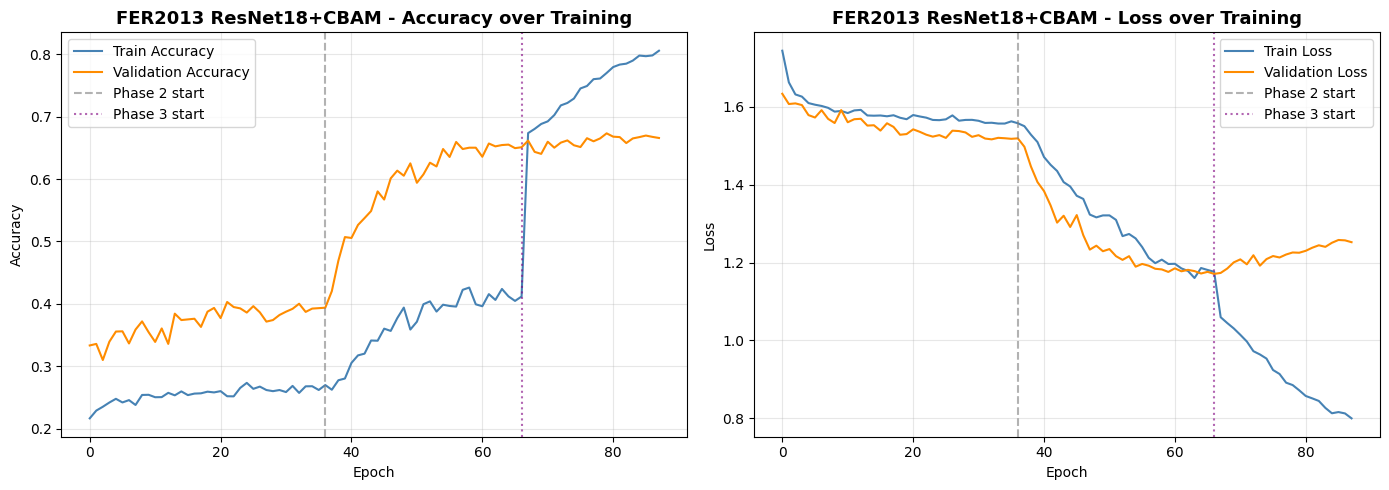

In [ ]:
# Training curves (all three phases)

combined_train_acc = (
    history['train_acc'] + history_p2['train_acc'] + history_p3['train_acc']
)
combined_val_acc = (
    history['val_acc'] + history_p2['val_acc'] + history_p3['val_acc']
)
combined_train_loss = (
    history['train_loss'] + history_p2['train_loss'] + history_p3['train_loss']
)
combined_val_loss = (
    history['val_loss'] + history_p2['val_loss'] + history_p3['val_loss']
)

p1_end = len(history['train_acc'])
p2_end = p1_end + len(history_p2['train_acc'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (tr, vl, label) in zip(axes, [
    (combined_train_acc, combined_val_acc, 'Accuracy'),
    (combined_train_loss, combined_val_loss, 'Loss')
]):
    ax.plot(tr, label=f'Train {label}', color='steelblue')
    ax.plot(vl, label=f'Validation {label}', color='darkorange')

    # Mark where Phase 2 and Phase 3 begin.
    ax.axvline(
        p1_end - 1,
        linestyle='--',
        color='gray',
        alpha=0.6,
        label='Phase 2 start'
    )
    ax.axvline(
        p2_end - 1,
        linestyle=':',
        color='purple',
        alpha=0.6,
        label='Phase 3 start'
    )

    ax.set_title(
        f'FER2013 ResNet18+CBAM - {label} over Training',
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fer2013_training_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Evaluate on test set with TTA (12 passes)

model.load_state_dict(torch.load(best_checkpoint))
model.eval()

print('Running evaluation with Test-Time Augmentation (12 passes)...')
y_pred, y_true = predict_with_tta(model, test_dataset, num_augmentations=11)

test_acc = (y_pred == y_true).mean()
print(f'Test Accuracy with TTA: {test_acc * 100:.2f}%')

label_indices = list(range(NUM_CLASSES))

report_str = classification_report(
    y_true, y_pred,
    labels=label_indices,
    target_names=VALID_CLASSES,
    digits=4
)
report_dict = classification_report(
    y_true, y_pred,
    labels=label_indices,
    target_names=VALID_CLASSES,
    output_dict=True
)

print('\nClassification Report - FER2013 Test Set')
print('=' * 60)
print(report_str)

# Save the final classification report as a text file.
with open('fer2013_classification_report_v2.txt', 'w') as f:
    f.write(report_str)

Running evaluation with Test-Time Augmentation (12 passes)...
Test Accuracy with TTA: 68.77%

Classification Report - FER2013 Test Set
              precision    recall  f1-score   support

       angry     0.6129    0.6263    0.6195       958
        fear     0.5957    0.5352    0.5638      1024
       happy     0.9396    0.7976    0.8628      1774
     neutral     0.6480    0.6375    0.6427      1233
         sad     0.5286    0.6592    0.5867      1247
    surprise     0.7707    0.8291    0.7988       831

    accuracy                         0.6877      7067
   macro avg     0.6826    0.6808    0.6791      7067
weighted avg     0.7022    0.6877    0.6919      7067



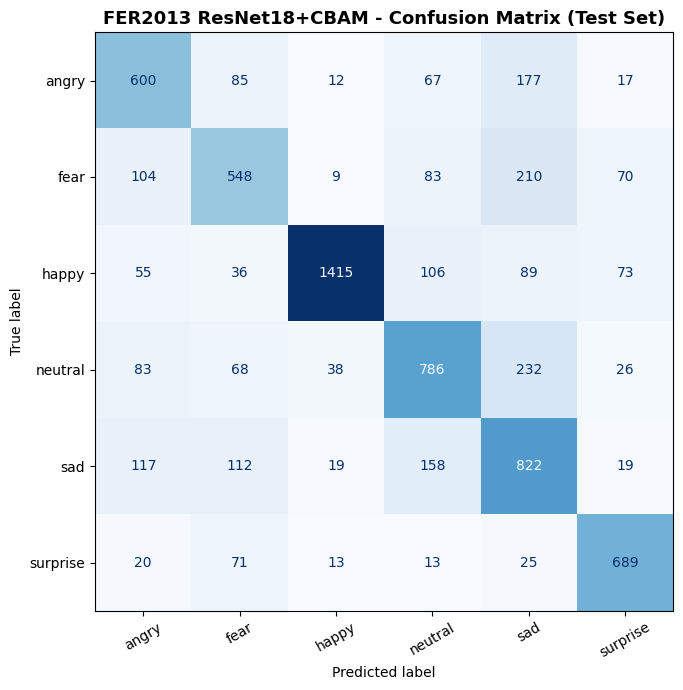

In [ ]:
#  Confusion matrix

cm = confusion_matrix(y_true, y_pred, labels=label_indices)

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=VALID_CLASSES).plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    xticks_rotation=30
)

ax.set_title(
    'FER2013 ResNet18+CBAM - Confusion Matrix (Test Set)',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('fer2013_confusion_matrix_v2.png', dpi=150, bbox_inches='tight')
plt.show()

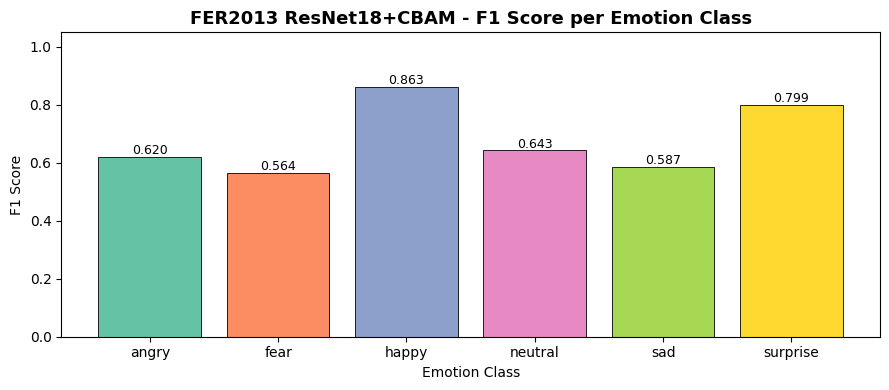

          precision  recall  f1-score  support
angry        0.6129  0.6263    0.6195    958.0
fear         0.5957  0.5352    0.5638   1024.0
happy        0.9396  0.7976    0.8628   1774.0
neutral      0.6480  0.6375    0.6427   1233.0
sad          0.5286  0.6592    0.5867   1247.0
surprise     0.7707  0.8291    0.7988    831.0


In [ ]:
# F1 score per class

# Take the per-class results from the classification report.
per_class = pd.DataFrame(report_dict).T.iloc[:NUM_CLASSES]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    VALID_CLASSES,
    per_class['f1-score'],
    color=sns.color_palette('Set2', NUM_CLASSES),
    edgecolor='black',
    linewidth=0.6
)

ax.set_title(
    'FER2013 ResNet18+CBAM - F1 Score per Emotion Class',
    fontsize=13,
    fontweight='bold'
)
ax.set_xlabel('Emotion Class')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)

# Show the F1 value above each bar.
for bar, v in zip(bars, per_class['f1-score']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.01,
        f'{v:.3f}',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('fer2013_f1_per_class_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(per_class[['precision', 'recall', 'f1-score', 'support']].round(4).to_string())

Correct: 4860
Wrong:   2207


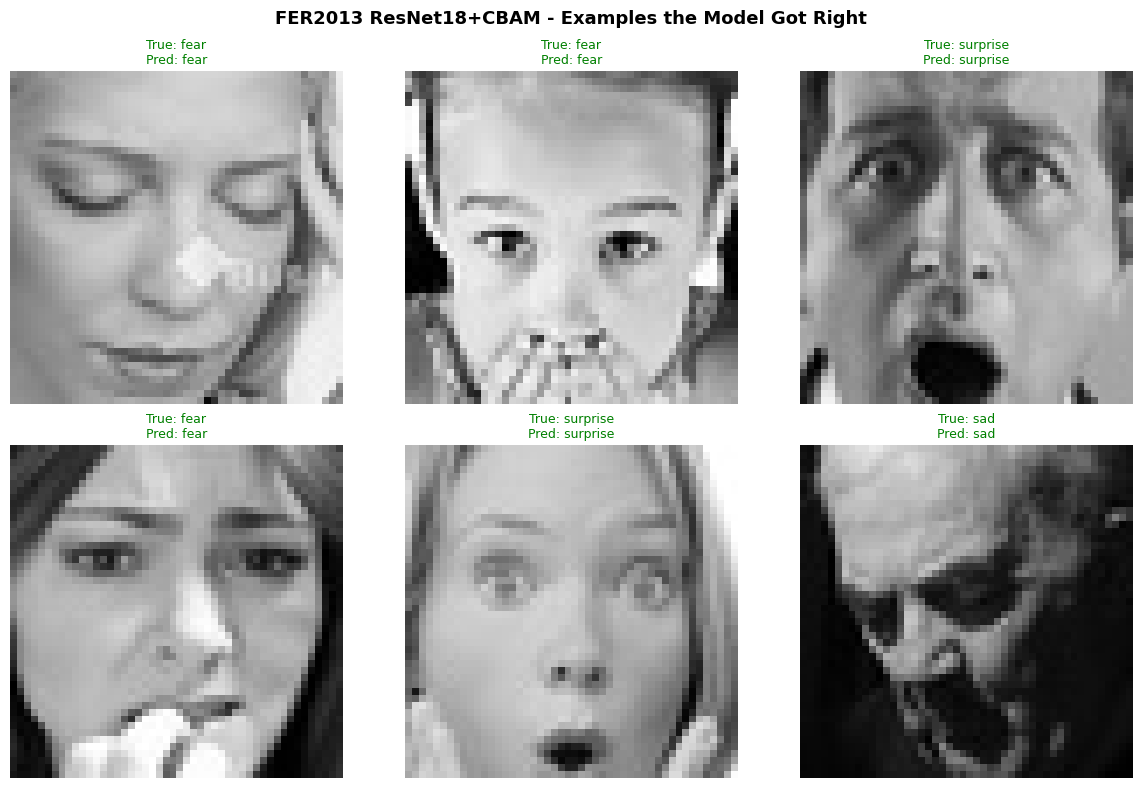

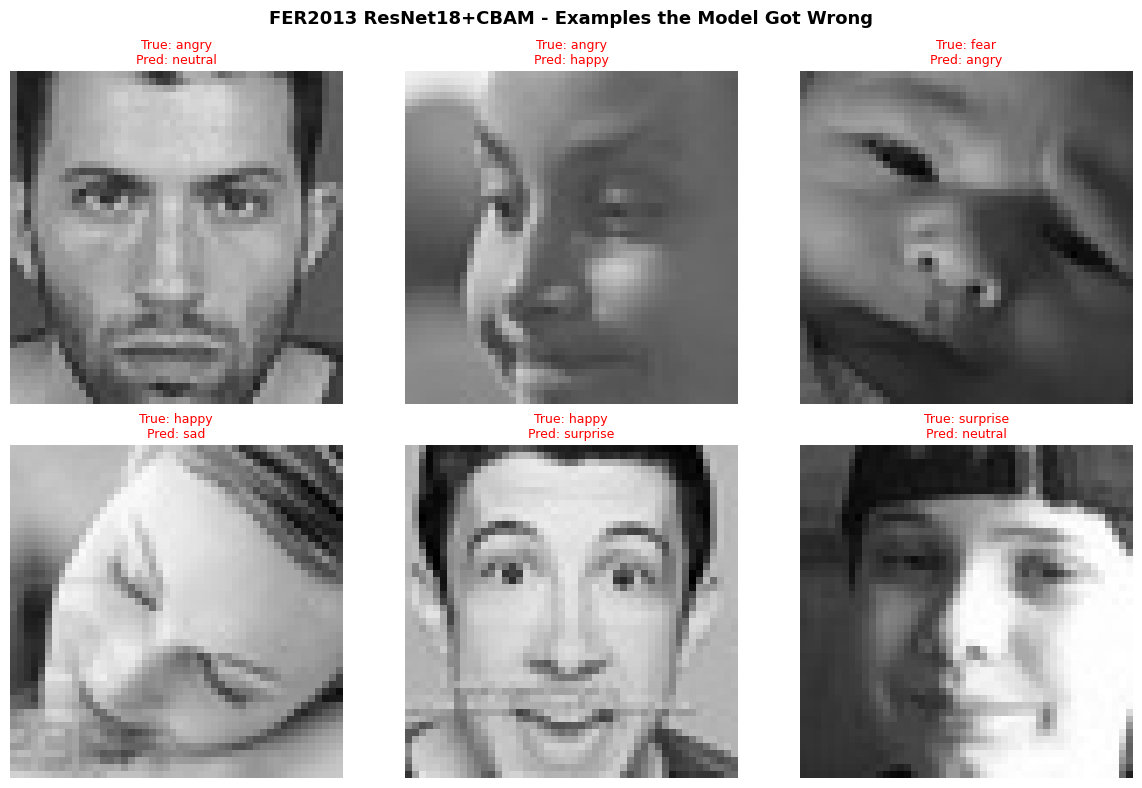

In [ ]:
#  Correct and misclassified examples

correct_idx = [i for i in range(len(y_true)) if y_true[i] == y_pred[i]]
wrong_idx = [i for i in range(len(y_true)) if y_true[i] != y_pred[i]]

print(f'Correct: {len(correct_idx)}')
print(f'Wrong:   {len(wrong_idx)}')


def show_predictions(indices, title, paths, n=6, filename=None):
    # Pick a few example images to display.
    sample = random.sample(indices, min(n, len(indices)))

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax, idx in zip(axes.flatten(), sample):
        img = Image.open(paths[idx]).convert('RGB')
        true_cls = VALID_CLASSES[y_true[idx]]
        pred_cls = VALID_CLASSES[y_pred[idx]]

        ax.imshow(img, cmap='gray')
        ax.set_title(
            f'True: {true_cls}\nPred: {pred_cls}',
            color='green' if true_cls == pred_cls else 'red',
            fontsize=9
        )
        ax.axis('off')

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


show_predictions(
    correct_idx,
    'FER2013 ResNet18+CBAM - Examples the Model Got Right',
    test_paths,
    filename='fer2013_correct_predictions_v2.png'
)

if wrong_idx:
    show_predictions(
        wrong_idx,
        'FER2013 ResNet18+CBAM - Examples the Model Got Wrong',
        test_paths,
        filename='fer2013_misclassified_v2.png'
    )

In [ ]:
#  Save all outputs to Drive

output_files = [
    'fer2013_class_distribution.png',
    'fer2013_sample_images.png',
    'fer2013_training_curves_v2.png',
    'fer2013_confusion_matrix_v2.png',
    'fer2013_f1_per_class_v2.png',
    'fer2013_correct_predictions_v2.png',
    'fer2013_misclassified_v2.png',
    'fer2013_classification_report_v2.txt',
]

for fname in output_files:
    src = Path(fname)
    dst = OUT / fname

    if src.exists():
        if dst.exists():
            dst.unlink()
        shutil.copy2(src, dst)
        print(f'Saved: {fname}')
    else:
        print(f'Not found: {fname}')

# Get the main summary numbers from the classification report.
macro = report_dict.get('macro avg', {})

print('\n' + '=' * 55)
print('FER2013 RESNET18+CBAM RESULTS SUMMARY (v2)')
print('=' * 55)
print(f'Test Accuracy   : {test_acc * 100:.2f}%')
print(f'Macro Precision : {macro.get("precision", 0):.4f}')
print(f'Macro Recall    : {macro.get("recall",    0):.4f}')
print(f'Macro F1        : {macro.get("f1-score",  0):.4f}')
print(f'Train samples   : {len(tr_paths)}')
print(f'Test samples    : {len(test_paths)}')
print('=' * 55)
print(f'\nv1 baseline: 67.27%')
print(f'Improvement : {(test_acc * 100) - 67.27:+.2f}pp')

Saved: fer2013_class_distribution.png
Saved: fer2013_sample_images.png
Saved: fer2013_training_curves_v2.png
Saved: fer2013_confusion_matrix_v2.png
Saved: fer2013_f1_per_class_v2.png
Saved: fer2013_correct_predictions_v2.png
Saved: fer2013_misclassified_v2.png
Saved: fer2013_classification_report_v2.txt

FER2013 RESNET18+CBAM RESULTS SUMMARY (v2)
Test Accuracy   : 68.77%
Macro Precision : 0.6826
Macro Recall    : 0.6808
Macro F1        : 0.6791
Train samples   : 25445
Test samples    : 7067

v1 baseline: 67.27%
Improvement : +1.50pp
